### 머신러닝 워크숍 15:00~16:50
- 아래 내용에 대해 최소 5개 이상 선택하여 실습해보세요.
- 다 실습하신 내용은 노트 및 py 파일들을 사번.zip 으로 압축해서 5월 6일 오후5시까지 제출하세요.
- 실습 문제 풀이는 5월 6일 오후 6시(예정) 혹은 6시 30분에 진행될 예정입니다.

#### 1. 시계열 자료인 005930_3.csv를 읽어서, 종가를 기준으로, 전일보다 올랐으면 1, 아니면 0인 y변수를 생성하세요. 주가가 올랐을 경우에 대해 패턴을 발견해보세요. 주가가 내리는 경우에 대한 군집을 발견해보세요.

- 패턴 발견을 위해 모든 변수값을 True/False로 변경해보세요. 예를 들어, 전일 대비 등락, 또는 평균보다 큰지를 비교하는 등의 계산을 해보세요.

- 군집 분석에서는, 기존 변수를 갖고 계산하고, 군지을 해석해 보세요.

In [56]:
import pandas as pd
import numpy as np
df = pd.read_csv("005930_3.csv")
df.head()


,날짜,시가,고가,저가,종가,거래량,등락률
0,2021-06-01,80500,81300,80100,80600,14058401,0.124224
1,2021-06-02,80400,81400,80300,80800,16414644,0.248139
2,2021-06-03,81300,83000,81100,82800,29546007,2.475248
3,2021-06-04,82700,82700,81500,82200,18112259,-0.724638
4,2021-06-07,82700,82800,81600,81900,16496197,-0.364964


In [57]:
df["y"] = np.where( df.등락률>0,1,0)

In [58]:
df1 = df.query("등락률>0")
df1["날짜"] = pd.to_datetime(df1.날짜)
df1["요일"] = df1.날짜.dt.dayofweek
df0 = pd.get_dummies(df1.요일)
df1.drop(columns=["날짜", "요일", "y"],inplace=True)

df1 = df1 > df1.mean()
df1 = pd.concat([df1, df0], axis=1)

C:\Users\user\AppData\Local\Temp\ipykernel_29096\993555364.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1["날짜"] = pd.to_datetime(df1.날짜)
C:\Users\user\AppData\Local\Temp\ipykernel_29096\993555364.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1["요일"] = df1.날짜.dt.dayofweek
C:\Users\user\AppData\Local\Temp\ipykernel_29096\993555364.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pa

In [59]:
!pip install mlxtend -q

In [60]:
from mlxtend.frequent_patterns import apriori, association_rules

frequent_itemsets = apriori(df1, min_support=0.05, use_colnames=True)
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.5)
rules.head(20)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(고가),(시가),0.480226,0.495292,0.474576,0.988235,1.995258,1.0,0.236724,42.900188,0.959670,0.947368,0.976690,0.973205
1,(시가),(고가),0.495292,0.480226,0.474576,0.958175,1.995258,1.0,0.236724,12.427324,0.988317,0.947368,0.919532,0.973205
2,(시가),(저가),0.495292,0.495292,0.489642,0.988593,1.995981,1.0,0.244328,44.246077,0.988677,0.977444,0.977399,0.988593
3,(저가),(시가),0.495292,0.495292,0.489642,0.988593,1.995981,1.0,0.244328,44.246077,0.988677,0.977444,0.977399,0.988593
4,(시가),(종가),0.495292,0.483992,0.476460,0.961977,1.987587,1.0,0.236742,13.570998,0.984485,0.947566,0.926313,0.973206
5,(종가),(시가),0.483992,0.495292,0.476460,0.984436,1.987587,1.0,0.236742,32.427495,0.962927,0.947566,0.969162,0.973206
6,(거래량),(시가),0.397363,0.495292,0.216573,0.545024,1.100409,1.0,0.019762,1.109306,0.151413,0.320334,0.098536,0.491143
7,(등락률),(시가),0.365348,0.495292,0.184557,0.505155,1.019913,1.0,0.003603,1.019931,0.030764,0.272981,0.019541,0.438889
8,(0),(시가),0.201507,0.495292,0.105461,0.523364,1.056679,1.0,0.005657,1.058897,0.067175,0.178344,0.055621,0.368146
9,(1),(시가),0.216573,0.495292,0.116761,0.539130,1.088510,1.0,0.009494,1.095121,0.103792,0.196203,0.086859,0.387436


In [61]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans

df2 = df.query("등락률==0")
df2_scaled = MinMaxScaler().fit_transform(df2[["시가", "고가", "저가", "종가"]])
kmeans = KMeans(n_clusters=3, random_state=0).fit(df2_scaled)
df2["cluster"] = kmeans.labels_
df2.head()

C:\Users\user\AppData\Local\Temp\ipykernel_29096\3264638598.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2["cluster"] = kmeans.labels_


,날짜,시가,고가,저가,종가,거래량,등락률,y,cluster
5,2021-06-08,82300,82600,81800,81900,12781226,0.0,0,0
8,2021-06-11,81200,81700,80700,81000,14087962,0.0,0,0
35,2021-07-20,78500,79000,78400,79000,12456646,0.0,0,0
49,2021-08-09,81500,82300,80900,81500,15522581,0.0,0,0
72,2021-09-10,75300,75600,74800,75300,10103212,0.0,0,2


#### 2.  1번에서, 기존 변수 및 파생변수들을 활용하여 X변수를 생성해보세요. 그리고 y에 대해 주가 등락을 모델링해보세요.

In [62]:
df["lag1"] =df.종가.shift(1)
df["lag2"] =df.종가.shift(2)
df["lag3"] =df.종가.shift(3)
df["v_lag1"] =df.거래량.shift(1)
df["dayofweek"] = pd.to_datetime(df.날짜).dt.dayofweek
df.dropna(inplace=True)
df.drop(columns=["날짜","시가","고가","저가", "종가", "거래량","등락률"], inplace=True)


In [63]:
from sklearn.model_selection import train_test_split
X = df.drop(columns=["y"])
y = df.y    
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)
X_train.head(), y_train.head()


(          lag1      lag2      lag3      v_lag1  dayofweek
 902    52700.0   51000.0   52400.0  27214851.0          2
 816    62600.0   63000.0   63100.0  28542376.0          1
 1109  109500.0  108400.0  105100.0  15527762.0          1
 739    73500.0   75200.0   77600.0  28551273.0          4
 311    59700.0   58800.0   58600.0  14203512.0          3,
 902     1
 816     1
 1109    0
 739     0
 311     0
 Name: y, dtype: int64)

In [65]:
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(random_state=0)
model.fit(X_train, y_train) 
y_pred = model.predict(X_test)
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.53      0.60      0.56       121
           1       0.45      0.38      0.41       104

    accuracy                           0.50       225
   macro avg       0.49      0.49      0.49       225
weighted avg       0.49      0.50      0.49       225



#### 3. satimage.csv에 대해서 3개 이상의 앙상블 모형으로 분류모델링을 해보시고 성능을 비교해보세요.

In [69]:
!pip install xgboost -q

In [70]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report
from xgboost import XGBClassifier

df = pd.read_csv("satimage.csv")
df.head()

X = df.drop(columns=["y"])
y = df.y

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

model1 = RandomForestClassifier(random_state=0)
model1.fit(X_train, y_train)
y_pred1 = model1.predict(X_test)

print(classification_report(y_test, y_pred1))

model2 = GradientBoostingClassifier(random_state=0)
model2.fit(X_train, y_train)
y_pred2 = model2.predict(X_test)

print(classification_report(y_test, y_pred2))

model3 = XGBClassifier(random_state=0)
model3.fit(X_train, y_train)
y_pred3 = model3.predict(X_test)

print(classification_report(y_test, y_pred3))



              precision    recall  f1-score   support

           0       0.98      0.97      0.98       301
           1       0.99      0.99      0.99       137
           2       0.88      0.94      0.91       280
           3       0.72      0.58      0.64       127
           4       0.90      0.91      0.90       150
           5       0.89      0.90      0.89       292

    accuracy                           0.91      1287
   macro avg       0.89      0.88      0.89      1287
weighted avg       0.90      0.91      0.90      1287

              precision    recall  f1-score   support

           0       0.98      0.97      0.98       301
           1       0.99      0.97      0.98       137
           2       0.88      0.92      0.90       280
           3       0.71      0.57      0.63       127
           4       0.86      0.91      0.88       150
           5       0.87      0.89      0.88       292

    accuracy                           0.90      1287
   macro avg       0.88

#### 4. nasa.csv에 대해서 3개 이상의 앙상블 모형으로 분류모델링을 해보시고 성능을 비교해보세요.

In [74]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report
from xgboost import XGBClassifier

df = pd.read_csv("nasa.csv", index_col=0)
df.dropna(inplace=True)


X = df.drop(columns=["label"])
y = df.label

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

model1 = RandomForestClassifier(random_state=0)
model1.fit(X_train, y_train)
y_pred1 = model1.predict(X_test)

print(classification_report(y_test, y_pred1))

model2 = GradientBoostingClassifier(random_state=0)
model2.fit(X_train, y_train)
y_pred2 = model2.predict(X_test)

print(classification_report(y_test, y_pred2))

model3 = XGBClassifier(random_state=0)
model3.fit(X_train, y_train)
y_pred3 = model3.predict(X_test)

print(classification_report(y_test, y_pred3))



              precision    recall  f1-score   support

           0       0.94      0.98      0.96      2566
           1       0.87      0.65      0.75       457

    accuracy                           0.93      3023
   macro avg       0.91      0.82      0.85      3023
weighted avg       0.93      0.93      0.93      3023

              precision    recall  f1-score   support

           0       0.90      0.98      0.94      2566
           1       0.83      0.41      0.55       457

    accuracy                           0.90      3023
   macro avg       0.86      0.70      0.74      3023
weighted avg       0.89      0.90      0.88      3023

              precision    recall  f1-score   support

           0       0.94      0.98      0.96      2566
           1       0.83      0.64      0.73       457

    accuracy                           0.93      3023
   macro avg       0.88      0.81      0.84      3023
weighted avg       0.92      0.93      0.92      3023



#### 5. mortDefault.csv를 이용해서, default를 예측하는 모형을 탐색을 활용하여 앙상블모형과 Isolation Forest를 각각 개발해서 성능을 비교해보세요. 그리고 좋은 성능 모형을 API로 서비스해보세요. 주어진 streamlit 템플릿을 이용해서, 웹에서 데이터 한 건씩 값을 입력 후, API호출해서 예측 결과를 출력하는 서비스를 만들어보세요. 그리고 API가 예측할 때마다, 그 내용을 DB의 테이블에 저장해보세요.(sqlite, duckdb, postgres 중 택1하여 만드세요)

In [91]:
df = pd.read_csv("mortDefault.csv")
df.drop(columns="year", inplace=True)
df["creditScore"] =df.creditScore.replace(["@@@","qqq"],[np.nan,np.nan]).astype(float)
df.dropna(inplace=True)
X = df.drop(columns=["default"])
y = df.default

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

C:\Users\user\AppData\Local\Temp\ipykernel_29096\680743420.py:1: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("mortDefault.csv")


In [92]:
from sklearn.ensemble import GradientBoostingClassifier, IsolationForest
#1 GBM
model1 = GradientBoostingClassifier(random_state=0)
model1.fit(X_train, y_train)
y_pred1 = model1.predict(X_test)
print(classification_report(y_test, y_pred1))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99    195081
           1       0.65      0.21      0.32      4918

    accuracy                           0.98    199999
   macro avg       0.82      0.61      0.66    199999
weighted avg       0.97      0.98      0.97    199999



In [96]:
from sklearn.metrics import (accuracy_score, roc_auc_score, f1_score)

iso_forest = IsolationForest(random_state=0)
iso_forest.fit(X_train)

def iso_predict(model, X):
    raw = model.predict(X)               # 1(정상), -1(이상치)
    return np.where(raw == -1, 1, 0)     # 이상치 → 양성(1), 정상 → 음성(0)


def iso_proba(model, X):
    scores = model.score_samples(X)      # 낮을수록 이상치
    # 이상 점수로 변환 후 0~1 범위로 정규화
    anomaly = -scores
    return (anomaly - anomaly.min()) / (anomaly.max() - anomaly.min())

# --- Isolation Forest ---
if_pred  = iso_predict(iso_forest, X_test)
if_proba = iso_proba(iso_forest, X_test)

print({
    'Model'   : 'IsolationForest',
    'Accuracy': accuracy_score(y_test, if_pred),
    'ROC-AUC' : roc_auc_score(y_test, if_proba),
    'F1'      : f1_score(y_test, if_pred)
})

{'Model': 'IsolationForest', 'Accuracy': 0.783718918594593, 'ROC-AUC': 0.7447129181670106, 'F1': 0.10867504636307439}


In [120]:
import joblib
joblib.dump(model1, "gbm_model_q5.pkl")    

['gbm_model_q5.pkl']

#### 6. 정밀가공_품질보증_데이터셋.csv를 읽으셔서 분류하는 모형을 만들어보세요. 날짜를 바탕으로 월, 요일, 오전/오후/저녁 등의 파생변수도 만들어 사용해보시고, 탐색을 사용해서 최적의 모형을 찾아보세요. 만들어진 모형은 pkl로 저장한 후, streamlit에서 불러와서, data 호출하는 api값에 대해 예측시켜보세요. 

In [109]:
df = pd.read_csv("정밀가공_품질보증_데이터셋.csv")

df['ReceivedDateTime'] = pd.to_datetime(df['ReceivedDateTime'])

# 날짜 파생변수
df['month'] = df['ReceivedDateTime'].dt.month
df['dayofweek'] = df['ReceivedDateTime'].dt.dayofweek
df['hour'] = df['ReceivedDateTime'].dt.hour
def time_zone(x):
    if 6 <= x < 12:
        return 0
    elif 12 <= x < 18:
        return 1
    elif 18 <= x < 24:
        return 2
    else:
        return 3

df['time_zone'] = df['hour'].apply(time_zone)
df.drop(columns=["ReceivedDateTime", "SerialNo"], inplace=True)
df.to_csv("api_data.csv", index=False)

In [112]:
X = df.drop(columns=["passorfail"])
y = df.passorfail

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

In [116]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import GradientBoostingClassifier

param_grid = {"n_estimators": [100, 200], "learning_rate": [0.01, 0.1]}
grid_search = GridSearchCV(GradientBoostingClassifier(random_state=0), param_grid, cv=5, scoring="precision", verbose=1)
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 4 candidates, totalling 20 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",GradientBoost...andom_state=0)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': [0.01, 0.1], 'n_estimators': [100, 200]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'precision'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also display

In [121]:
import joblib
best_model = grid_search.best_estimator_    
joblib.dump(best_model, "gbm_model_q6.pkl")

['gbm_model_q6.pkl']

#### 7. 시지트로닉스 데이터에 대해서 이미지를 분류하는 모형을 만들어보세요. 앙상블모형과 DT 모형의 성능을 비교해보세요.

In [122]:
import numpy as np
from PIL import Image
import os, glob, random

max_photo = 150
photo_size=32

In [123]:
import os
import glob
import random
dirs = os.listdir("Dataset")

In [132]:
def img_read(dir):
  files = glob.glob( "Dataset/"+dir+"/*.png")
  #random.shuffle(files)
  num=0
  tmp1 = []
  tmp2 = []
  print(len(files), dir, num)
  for f in files:
    print(f)
    if num >= max_photo: break
    num +=1
    img = Image.open(f)
    img= img.convert("RGB")
    img= img.resize((photo_size, photo_size))
    img= np.asarray(img)
    tmp1.append(img)
    tmp2.append(dir)	#label을 0으로 지정
  return tmp1, tmp2

In [133]:
x=[]
y=[]

for dir in dirs:
  print(dir)
  x1, y1 = img_read(dir)
  x.append(x1)
  y.append(y1)

AREA
50 AREA 0
Dataset/AREA\001.png
Dataset/AREA\002.png
Dataset/AREA\003.png
Dataset/AREA\004.png
Dataset/AREA\005.png
Dataset/AREA\006.png
Dataset/AREA\007.png
Dataset/AREA\008.png
Dataset/AREA\009.png
Dataset/AREA\010.png
Dataset/AREA\011.png
Dataset/AREA\012.png
Dataset/AREA\013.png
Dataset/AREA\014.png
Dataset/AREA\015.png
Dataset/AREA\016.png
Dataset/AREA\017.png
Dataset/AREA\018.png
Dataset/AREA\019.png
Dataset/AREA\020.png
Dataset/AREA\021.png
Dataset/AREA\022.png
Dataset/AREA\023.png
Dataset/AREA\024.png
Dataset/AREA\025.png
Dataset/AREA\026.png
Dataset/AREA\027.png
Dataset/AREA\028.png
Dataset/AREA\029.png
Dataset/AREA\030.png
Dataset/AREA\031.png
Dataset/AREA\032.png
Dataset/AREA\033.png
Dataset/AREA\034.png
Dataset/AREA\035.png
Dataset/AREA\036.png
Dataset/AREA\037.png
Dataset/AREA\038.png
Dataset/AREA\039.png
Dataset/AREA\040.png
Dataset/AREA\041.png
Dataset/AREA\042.png
Dataset/AREA\043.png
Dataset/AREA\044.png
Dataset/AREA\045.png
Dataset/AREA\046.png
Dataset/AREA\047.pn

In [134]:
x_final = [item for sublist in x for item in sublist]
y_final = [item for sublist in y for item in sublist]

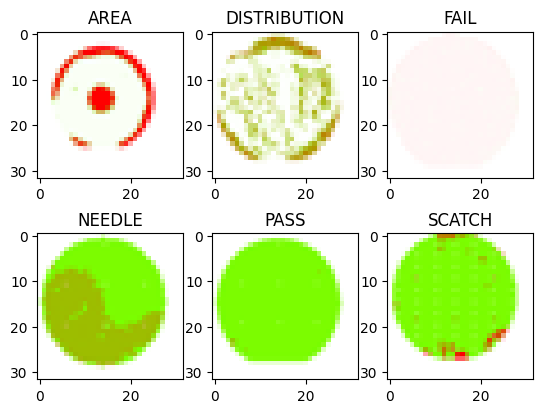

In [135]:
#이미지 출력
import matplotlib.pyplot as plt
idx = 50
for i in range(6):
 plt.subplot(2,3,i+1)
 plt.title(y_final[i*idx])
 plt.imshow(x_final[i*idx])
plt.show()

In [141]:
import pandas as pd
X_arr = np.array(x_final).reshape(-1, 32*32*3)
y_arr = np.array(y_final)

X_df = pd.DataFrame(X_arr)
y_df = pd.DataFrame(y_arr)

In [142]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split( X_df, y_df, test_size=0.2, random_state=123, stratify=y_df_ohe)

In [143]:
import numpy as np
import pandas as pd
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score, classification_report


In [ ]:
# GBM
model = GradientBoostingClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    n_iter_no_change=50,
    validation_fraction=0.1,
    tol=1e-4,
    random_state=42
)
model.fit(X_train, y_train)



c:\Users\user\miniconda3\envs\day3\Lib\site-packages\sklearn\preprocessing\_label.py:120: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [146]:
y_pred  = model.predict(X_test)
y_proba = model.predict_proba(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

        AREA       0.71      1.00      0.83        10
DISTRIBUTION       0.86      0.60      0.71        10
        FAIL       1.00      1.00      1.00        10
      NEEDLE       0.89      0.80      0.84        10
        PASS       0.91      1.00      0.95        10
      SCATCH       0.89      0.80      0.84        10

    accuracy                           0.87        60
   macro avg       0.88      0.87      0.86        60
weighted avg       0.88      0.87      0.86        60



#### 8. secom.data, secom_labels.data에 대해서 제일 성능 좋은 분류 모형을 만들어보세요.